In [2]:
import requests
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import datetime
from wordcloud import WordCloud

fission = "http://localhost:9090"

## Sentiment Across Platforms

In [3]:
def format_date(date):
    return date.strftime("%Y-%m-%d")

def dataframe(data, start, end):
    start_date = datetime.datetime.fromisoformat(start)
    end_date = datetime.datetime.fromisoformat(end)
    num_days = (end_date - start_date).days
    date_list = [format_date(start_date + datetime.timedelta(days=x)) for x in range(num_days + 1)]
    df = pd.DataFrame.from_dict(data, orient="index").reindex(date_list)
    return df

labels = {
    "openaus": "Open Australia",
    "bluesky": "Bluesky",
    "reddit": "Reddit"
}

entity_labels = {
    "ORG": "Organisations",
    "PER": "People",
    "LOC": "Locations",
    "EVENT": "Events",
}


In [32]:
def plot_source_sentiment(table, start, end, data=None, percentages=False):
    if data is None:
        response = requests.get(
                url=f"{fission}/ui/sentiment/keyword/*/start/{start}/end/{end}",
                timeout=1500
            )
    
        if response.status_code != 200:
            print(response, response.text)
            return 
            
        data = response.json()
    
    # plot
    fig, ax = plt.subplots(len(table), 2, sharex=True, figsize=(12, 3 * len(table)))

    for i, s in enumerate(table):
        if len(table) == 1:
            ax0, ax1 = ax[0], ax[1]
        else:
            ax0, ax1 = ax[i, 0], ax[i, 1]
        
        df = dataframe(data[s], start, end)
        ax0.set_ylabel("Sentiment", loc="center")
        
        cols = ["neg", "neu", "pos"]
        total = sum([df[col] for col in cols])
        columns = [df[col] / total for col in cols]
        
        ax0.stackplot(df.index, columns, labels=cols, colors=["firebrick", "wheat", "forestgreen"], alpha=0.8)   
        ax0.legend(loc="upper right")
        ax0.set_title(f"{labels[s]} sentiment")
        ax0.set_ylim(bottom=0)
        # add percentage labels
        if percentages:
            for x_idx, x in enumerate(df.index):
                # label every second date
                if x_idx % 2 == 0:
                    continue
                y_bottom = 0
                for j, col in enumerate(cols):
                    height = columns[j].iloc[x_idx] 
                    # only label if its at least 5%
                    if height >= 0.05: 
                        ax0.text(x, y_bottom + height/2, f"{int(height*100)}%", ha='center', va='center', fontsize=8, color="black")
                    y_bottom += height

        ax1.set_ylabel("Count", loc="center")

        ax1.plot(total.index, total.values, color='tab:blue')
        ax1.fill_between(total.index, 0, total.values, color='tab:blue')
        ax1.set_title(f"{labels[s]} document count")
        ax1.set_ylim(bottom=0)
    
        # label the x axis with dates
        ax0.set_xticks(range(len(df)), labels=df.index, rotation=30, ha="right", rotation_mode="anchor")
        ax0.xaxis.set_major_locator(plt.matplotlib.dates.AutoDateLocator())
        
        ax1.set_xticks(range(len(df)), labels=df.index, rotation=30, ha="right", rotation_mode="anchor")
        ax1.xaxis.set_major_locator(plt.matplotlib.dates.AutoDateLocator())

    plt.tight_layout()
    #plt.show()

    return data


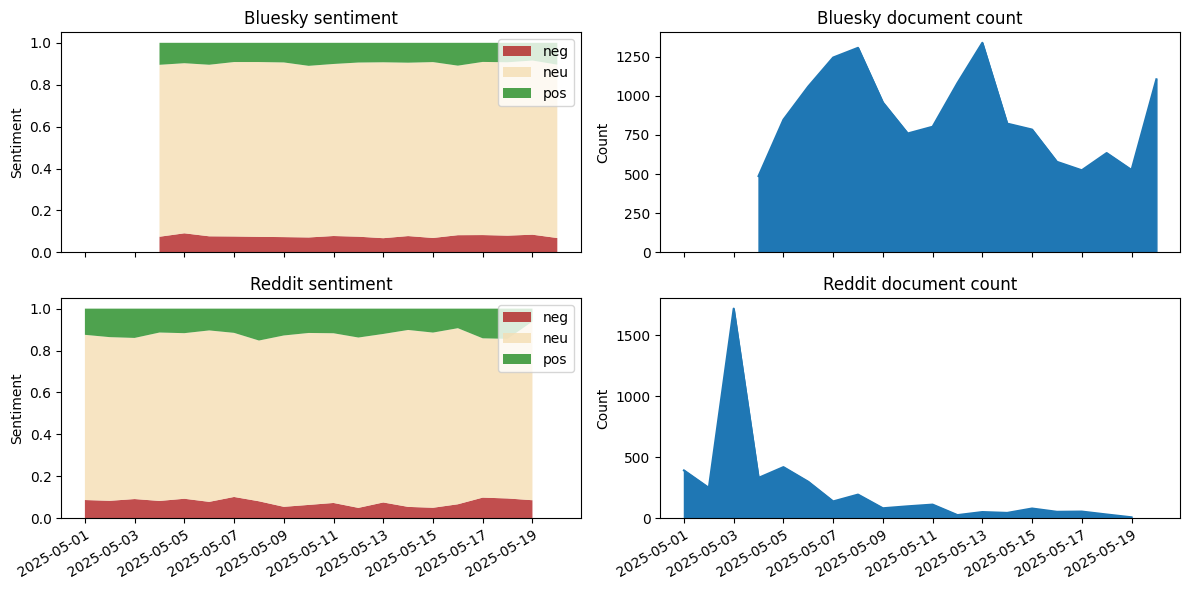

In [33]:
today = datetime.datetime.now().strftime("%Y-%m-%d")
df = plot_source_sentiment(["bluesky", "reddit"], "2025-05-01", today)
plt.savefig('../docs/report_images/bluesky_reddit_sentiment.png')

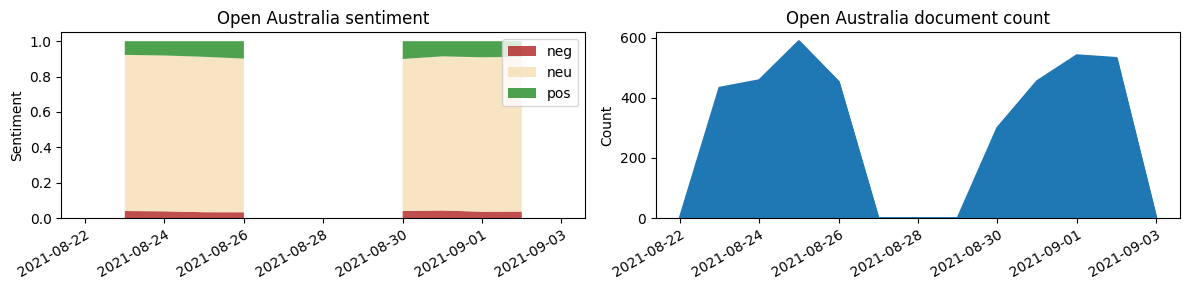

In [34]:
openaus = plot_source_sentiment(["openaus"], "2021-08-22", "2021-09-03")
plt.savefig('../docs/report_images/open_aus_sentiment.png')

## Word Clouds

In [35]:
def get_wordcloud_data(label):
    response = requests.get(
        url=f"{fission}/ui/named-entities/label/{label}",
        timeout=10000
    )

    if response.status_code != 200:
        print(response, response.text)
        return 
        
    data = response.json()
    if label == "PERSON":
        data["bluesky"]["auspol"] = 0

    return data

def wordcloud_from_data(label, data): 
    fig, ax = plt.subplots(2, 2, figsize=(15, 9))
    for i, s in enumerate(labels):
        wordcloud = WordCloud(background_color="white", max_font_size=40).generate_from_frequencies(data[s])
        ax[i // 2, i % 2].imshow(wordcloud, interpolation="bilinear")
        ax[i // 2, i % 2].axis("off")
        ax[i // 2, i % 2].set_title(labels[s], fontsize=20)

    ax[1, 1].axis("off")
    plt.tight_layout()
    plt.suptitle(f"Word Cloud for entities of type \"{label}\" across platforms", fontsize=30, y=1.05)
    # plt.subplots_adjust(top=0.9)

    #plt.show()


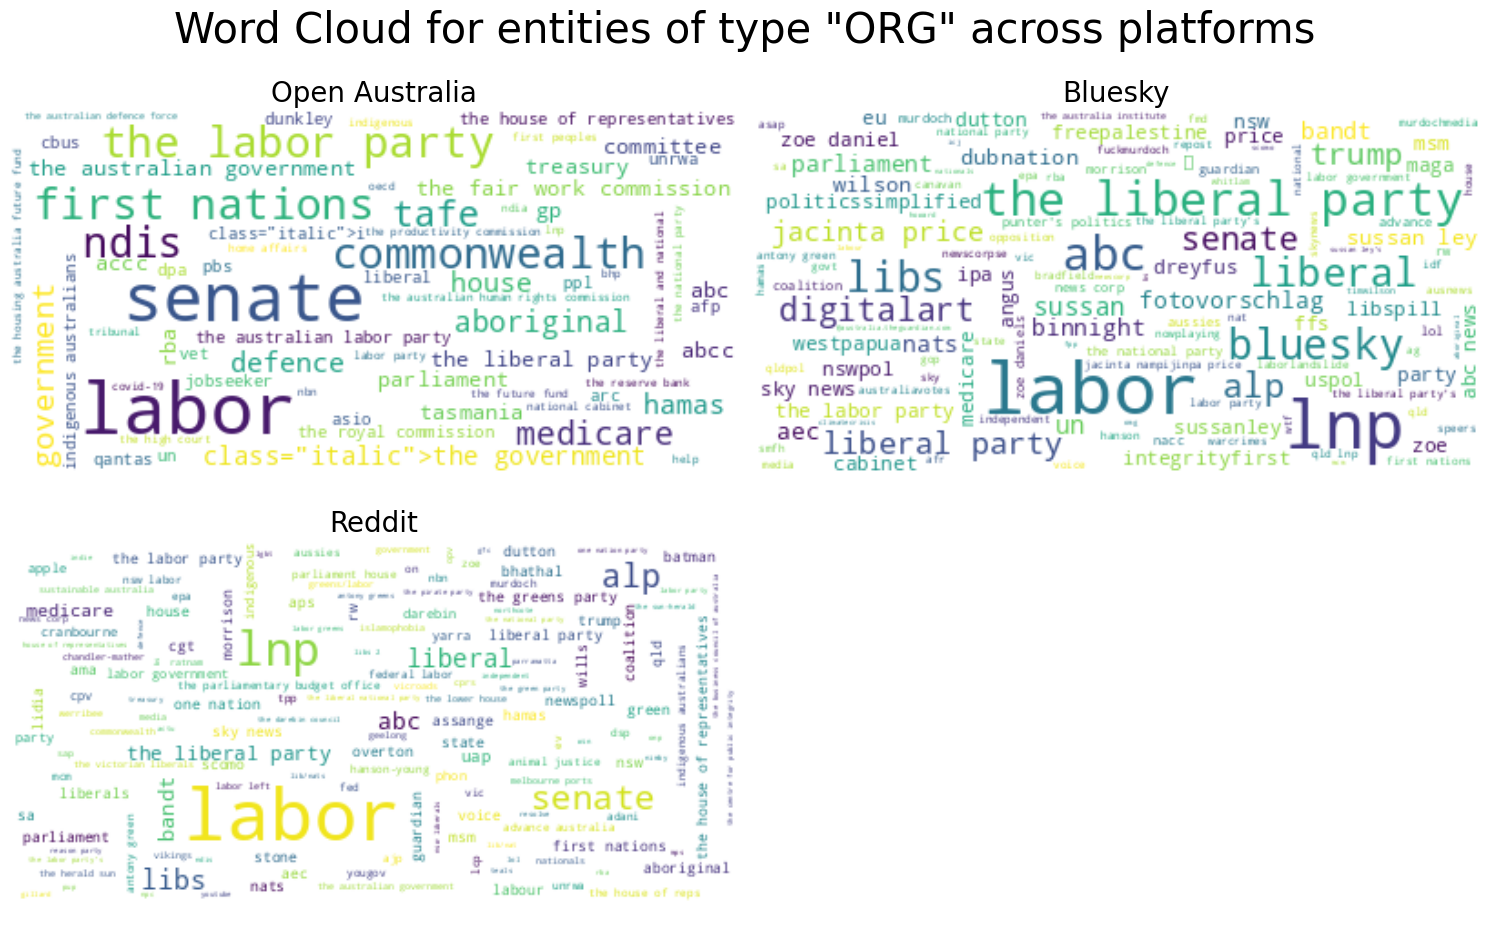

In [36]:
org_data = get_wordcloud_data("ORG")
wordcloud_from_data("ORG", org_data)
plt.savefig('../docs/report_images/org_wordcloud.png')

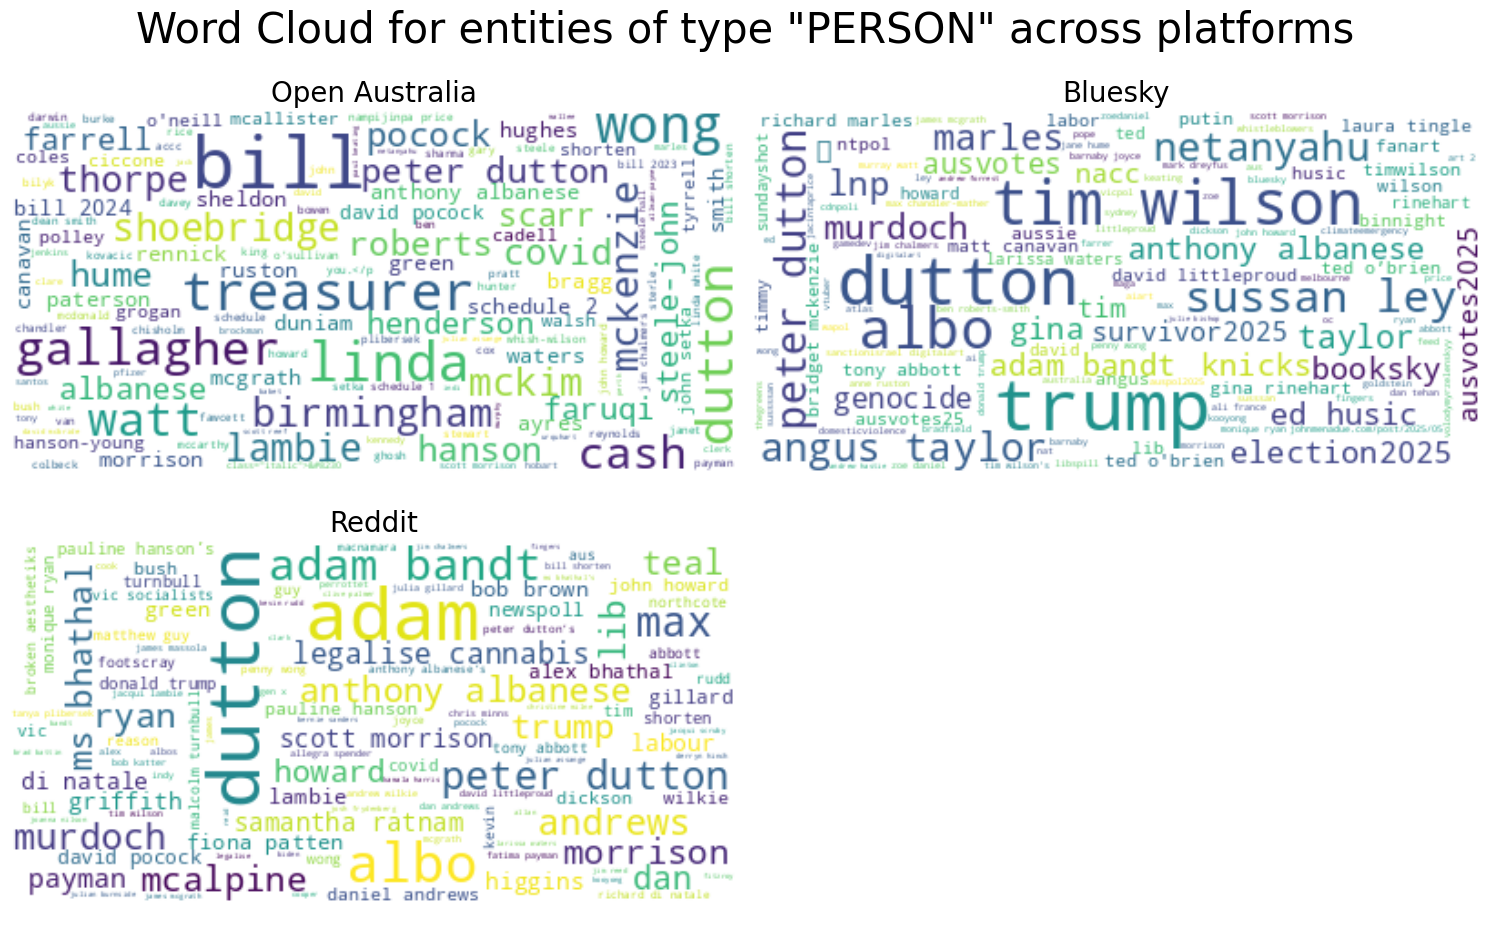

In [37]:
person_data = get_wordcloud_data("PERSON")
wordcloud_from_data("PERSON", person_data)
plt.savefig('../docs/report_images/person_wordcloud.png')

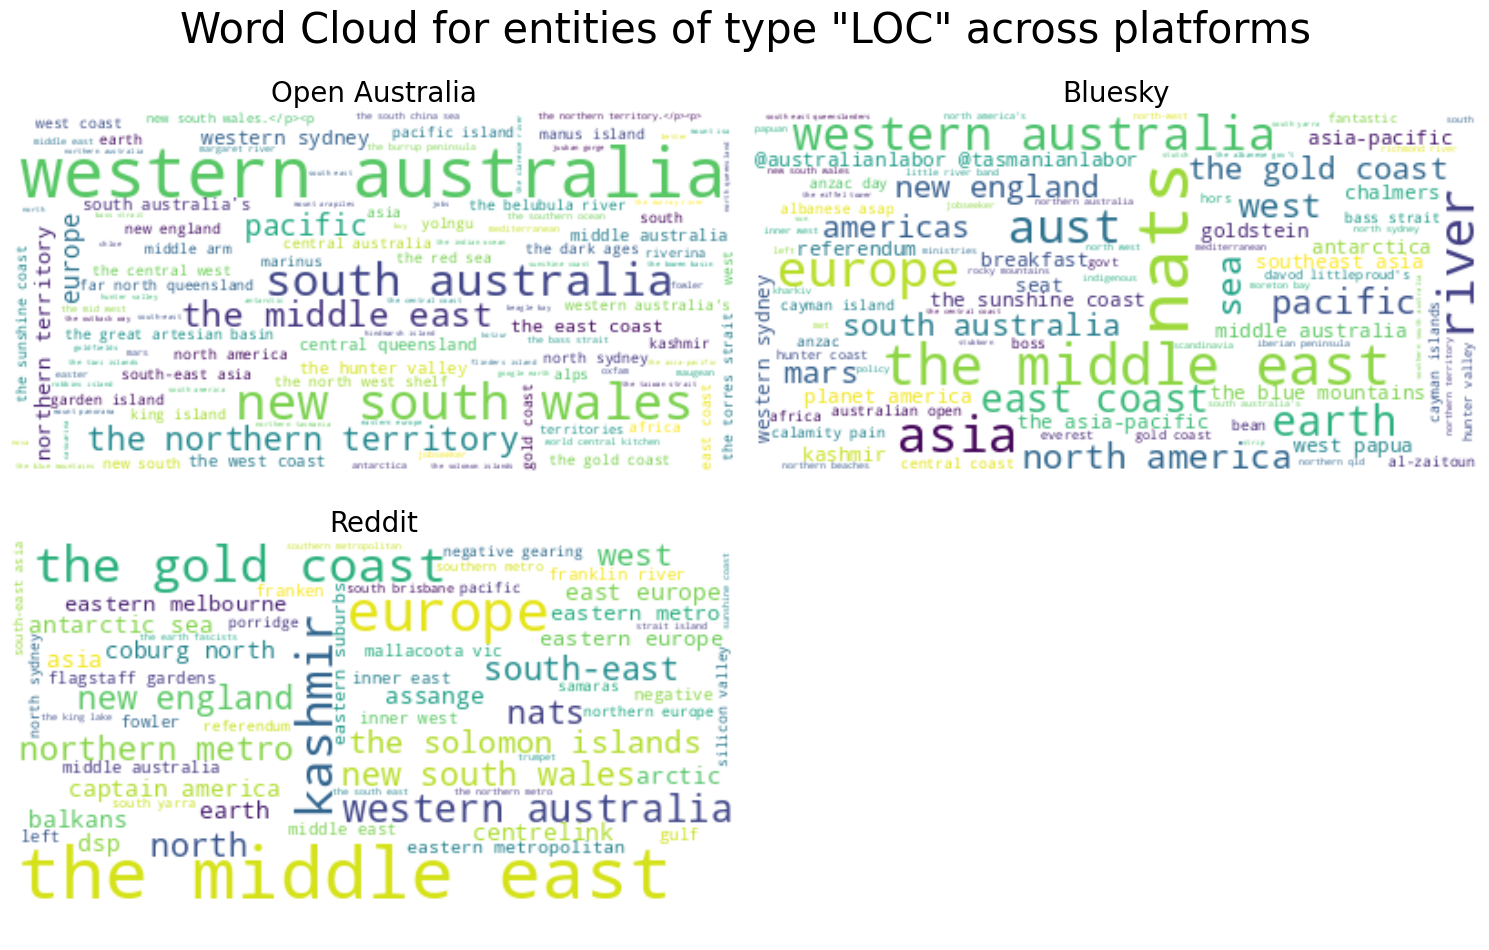

In [49]:
loc_data = get_wordcloud_data("LOC")
wordcloud_from_data("LOC", loc_data)
plt.savefig('../docs/report_images/loc_wordcloud.png')

In [40]:
def get_top_each_platform(data, count=10, normalise=False):
    """
    takes a wordcloud data dict with keys for each platform,
    returns a dict of top n items for each platform.
    """
    top_dict = {}
    # sort words by frequency (desc)
    for platform, freq_dict in data.items():
        sorted_items = sorted(freq_dict.items(), key=lambda x: x[1], reverse=True)[:count]
        if normalise:
          total = sum([v for _, v in sorted_items])
          if total > 0:
              sorted_items = [(k, v / total) for k, v in sorted_items]
          else:
              sorted_items = [(k, 0) for k, v in sorted_items]

        top_dict[platform] = sorted_items
    return top_dict


def plot_top_each_platform(data, label, normalised=True):
    fig, ax = plt.subplots(2, 2, figsize=(15, 9))
    for i, s in enumerate(labels):
        sorted_items = sorted(data[s], key=lambda x: x[1], reverse=True)[:10]
        items = [item[0] for item in sorted_items]
        values = [item[1] for item in sorted_items]
        ax[i // 2, i % 2].barh(items, values)
        ax[i // 2, i % 2].set_title(labels[s])
        ax[i // 2, i % 2].invert_yaxis()
        ax[i // 2, i % 2].set_xlabel("frequency" if normalised else "count")

    plt.suptitle(f"Frequency of entities of type \"{label}\" across platforms", fontsize=30, y=1)

    ax[1, 1].axis("off")
    plt.tight_layout()
    #plt.show()



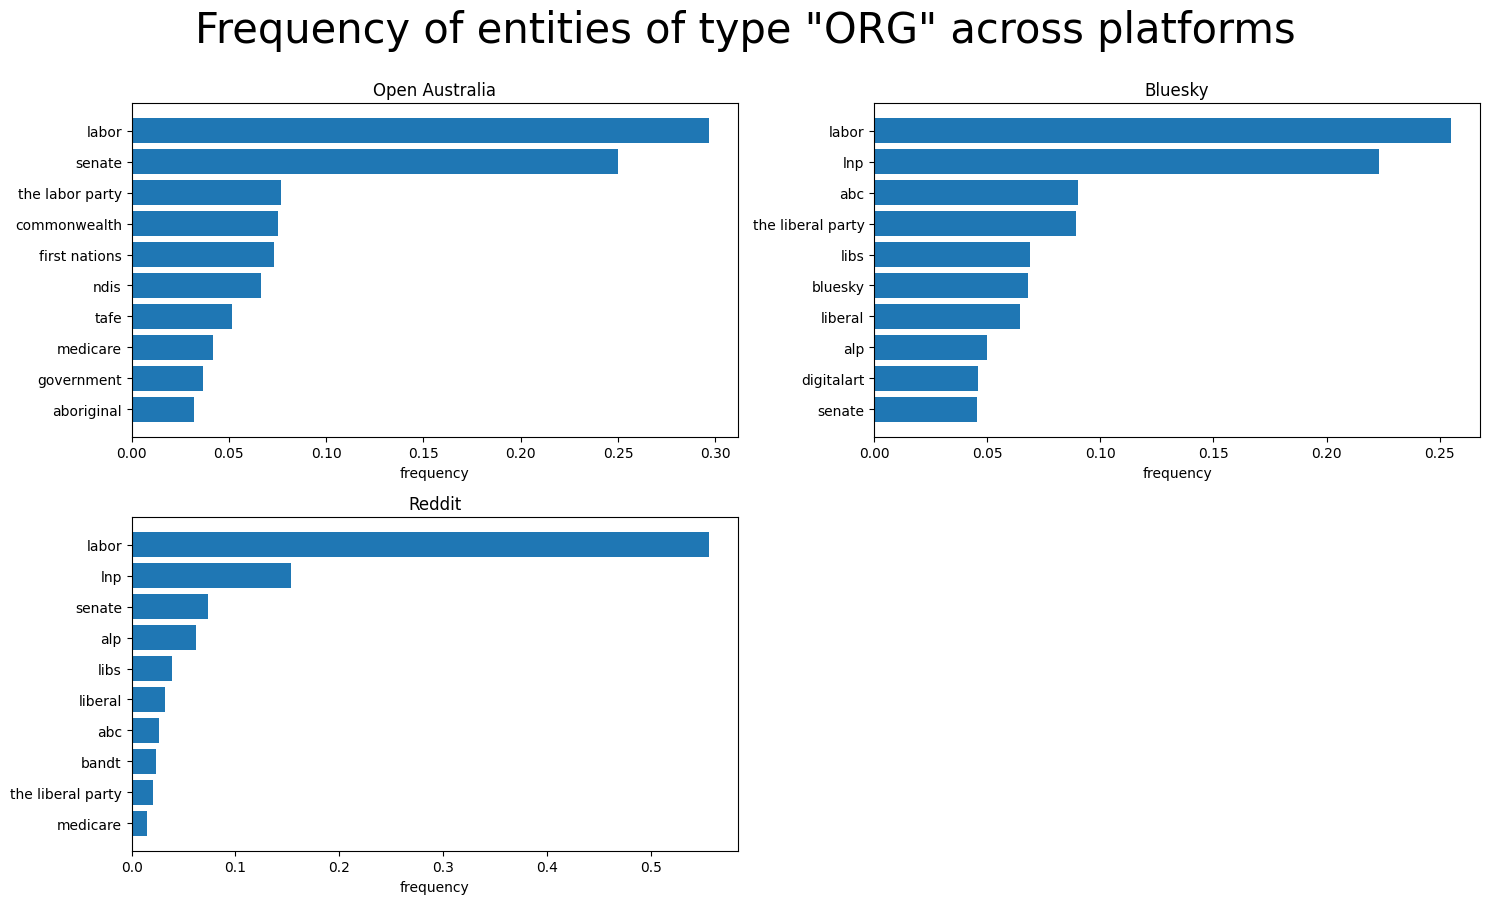

In [41]:
org_top = get_top_each_platform(org_data, count=10, normalise=True)
plot_top_each_platform(org_top,  "ORG", normalised=True)
plt.savefig('../docs/report_images/org_freq.png')

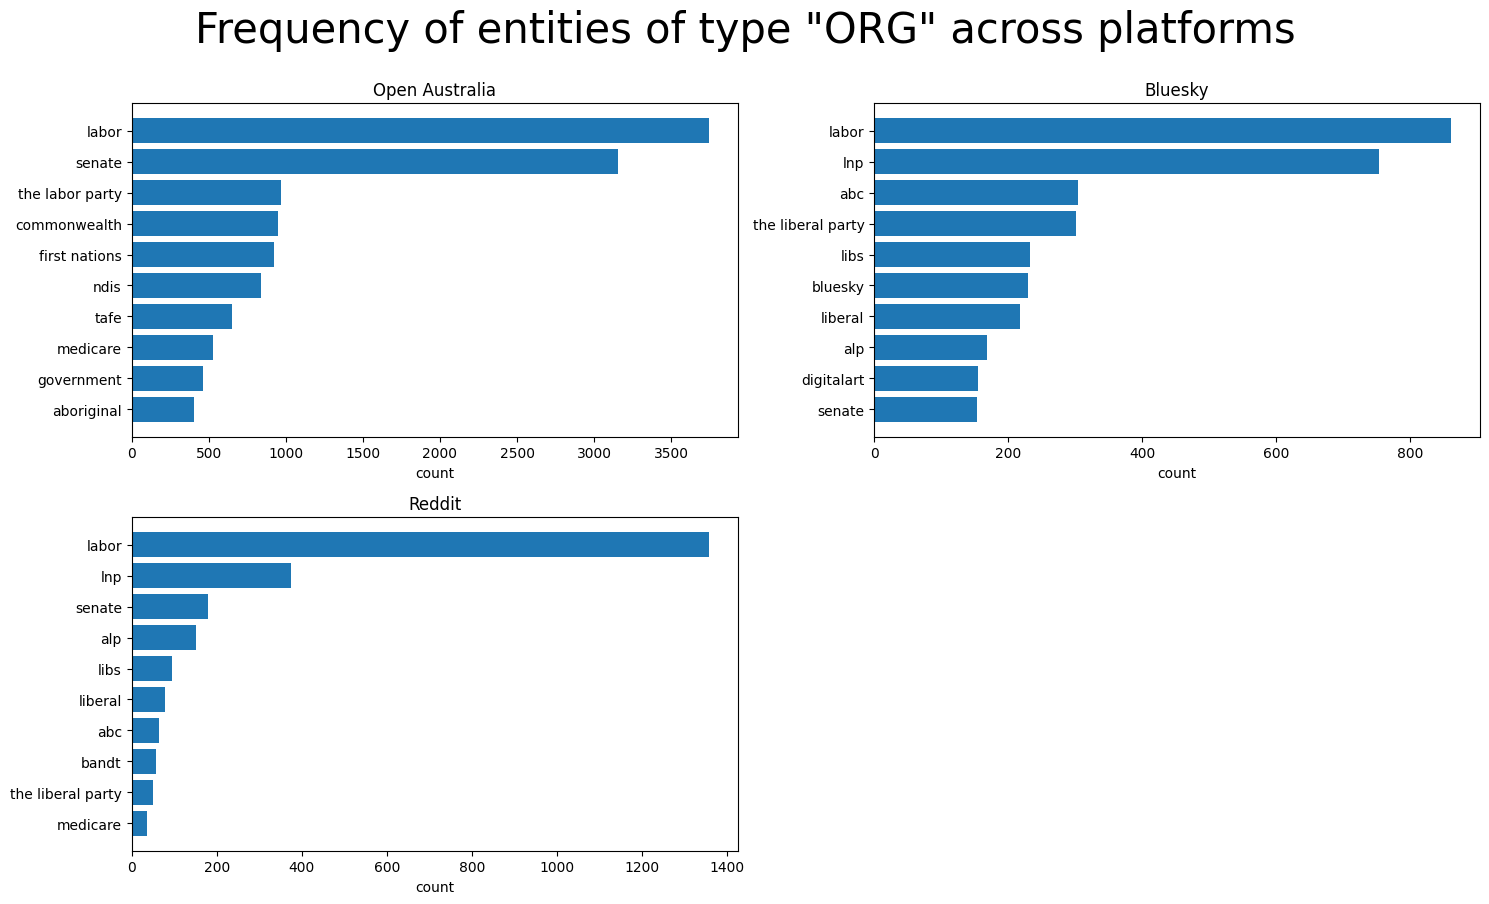

In [48]:
org_top_count = get_top_each_platform(org_data, count=10, normalise=False)
plot_top_each_platform(org_top_count, "ORG", normalised=False)

## Sentiment Across Platforms by Keyword

In [43]:
def plot_sentiment_across_platforms(fission_url, keyword_list, keyword_type, results=None):
    """
    Gets the averaged sentiments by keyword from the sentiment-averager Fission function
    and plots sentiment for each keyword across platforms (reddit, bluesky, openaus).
    and displays the results in a nice little horizontal stacked bar chart. yay!
    """
    if results is None:
      # allows testing without having to calculate every tiem yay!
      url = f"{fission_url}/ui/sentiment-averager/type/{keyword_type}"
      headers = {"X-Fission-Params-type": keyword_type}
      data = {"keywords": keyword_list}
      response = requests.post(url, headers=headers, json=data, timeout=1000)
      if response.status_code != 200:
          print("Error:", response.text)
          return

      results = response.json()

    platforms = ["bluesky", "reddit", "openaus"]
    # ignore compound 
    sentiment_keys = ["neg", "neu", "pos"] # "compound"]
    # i really love the python colors theyre so funny to me
    colors = ["firebrick", "wheat", "forestgreen"]  

    for keyword in keyword_list:
        # format data 
        sentiment_data = []
        counts = []
        for platform in platforms:
            platform_data = results.get(platform, {}).get(keyword, {})
            sentiment = platform_data.get("sentiment", None)
            count = platform_data.get("count", 0)
            if sentiment:
                sentiment_data.append([sentiment.get(k, 0) for k in sentiment_keys])
            else:
                sentiment_data.append([0, 0, 0])
            counts.append(count)

        sentiment_data = np.array(sentiment_data)

        # stacked bar chart!
        y = np.arange(len(platforms))
        fig, ax = plt.subplots(figsize=(8, 4))
        left = np.zeros(len(platforms))
        for i, sentiment_key in enumerate(sentiment_keys):
            ax.barh(y, sentiment_data[:, i], color=colors[i], label=sentiment_key, left=left)
            left += sentiment_data[:, i]

        ax.set_yticks(y)
        ax.set_yticklabels([labels[p] for p in platforms])
        ax.set_xlabel("Percentage")
        ax.set_xlim(0, 1)
        ax.set_title(f"Sentiment across platforms for '{keyword_type}' keyword: '{keyword}'")
        ax.legend(loc="lower right")

        # percentage labels and counts
        for i in range(len(platforms)):
            xpos = 0
            for j in range(len(sentiment_keys)):
                width = sentiment_data[i, j]
                # only if theres data 
                if width > 0: 
                    ax.text(xpos + width/2, i, f"{int(width*100)}%", va='center', ha='center', color="black", fontsize=9)
                xpos += width
            ax.text(1.02, i, f"n={counts[i]}", va='center', ha='left', fontsize=9)

        plt.tight_layout()
        #plt.show()
    return results


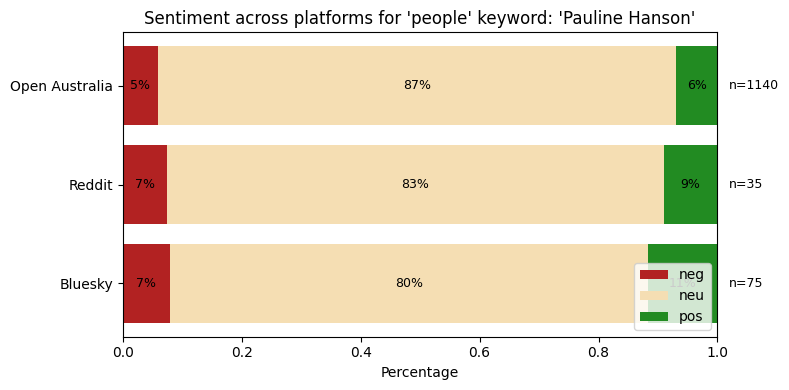

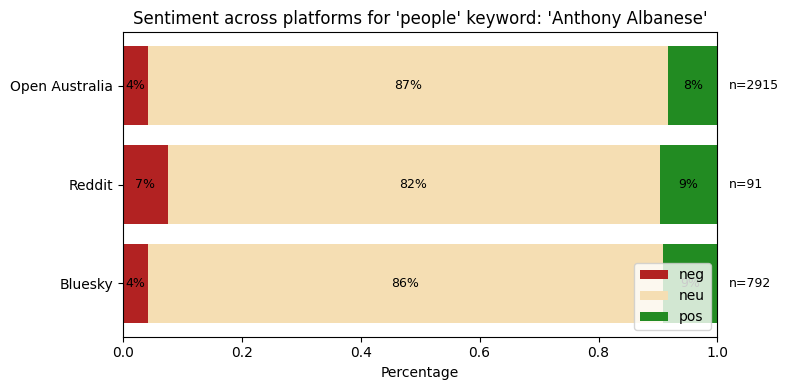

In [44]:
results = plot_sentiment_across_platforms(
    fission_url=fission,
    keyword_list=["Pauline Hanson"],
    keyword_type="people",
    results=None
)
plt.savefig('../docs/report_images/pauline_sent_avg.png')

results = plot_sentiment_across_platforms(
    fission_url=fission,
    keyword_list=["Anthony Albanese"],
    keyword_type="people",
    results=None
)
plt.savefig('../docs/report_images/albo_sent_avg.png')

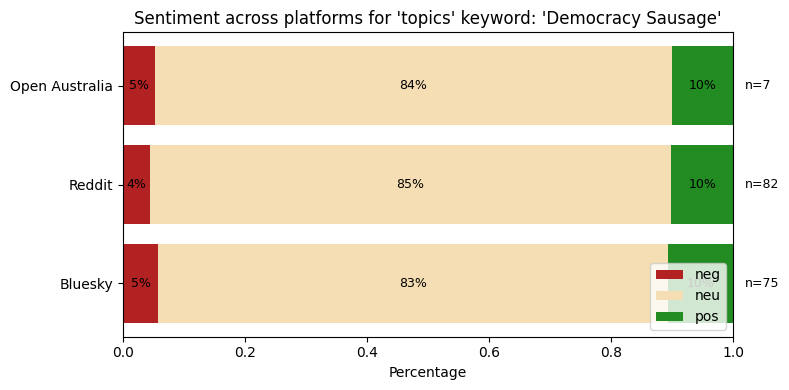

In [45]:
snags = plot_sentiment_across_platforms(
    fission_url=fission,
    keyword_list=["Democracy Sausage"],
    keyword_type="topics",
    results=None
)

## Post Counts

In [46]:
def format_data(table, start):
    start_date = datetime.datetime.fromisoformat(start)
    end_date = datetime.datetime.now()
    num_days = (end_date - start_date).days
    date_list = [format_date(start_date + datetime.timedelta(days=x)) for x in range(num_days + 1)]

    dates = [e['key_as_string'].split("T")[0] for e in table]
    counts = [e['doc_count'] for e in table]
    df = pd.DataFrame(counts, index=dates, columns=['doc_count']).reindex(date_list)
    return df


def comparison_plot_keyword_counts(platforms, start, keyword, data=None, normalise=True):
    """
    frequency of keywords over time on one graph, rather than 3
    if normalise each platform's counts are divided by their max (so all lines go from 0 to 1).
    """
    if data is None:
        response = requests.get(
            url=f"{fission}/ui/counts/start/{start}/keyword/{keyword}",
            timeout=600
        )
        if response.status_code != 200:
            print(response, response.text)
            return 
        data = response.json()

    plt.figure(figsize=(14, 6))
    for s in platforms:
        df = format_data(data[s], start)
        y = df['doc_count'].fillna(0)
        if normalise and y.max() > 0:
            y = y / y.max()
        plt.plot(df.index, y, label=labels[s])
        plt.fill_between(df.index, 0, y, alpha=0.1)
    # date labels so they dont overlap
    ax = plt.gca()
    ax.xaxis.set_major_locator(plt.matplotlib.dates.AutoDateLocator())
    # ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))
    plt.gcf().autofmt_xdate()  

    plt.suptitle(f"Document Counts containing '{keyword}' Across Platforms", fontsize=20)
    plt.xlabel("Date")
    plt.ylabel("Normalized Count" if normalise else "Count")
    # plt.xticks(rotation=30, ha="right")
    plt.legend()
    plt.tight_layout()
    #plt.show()

    return data

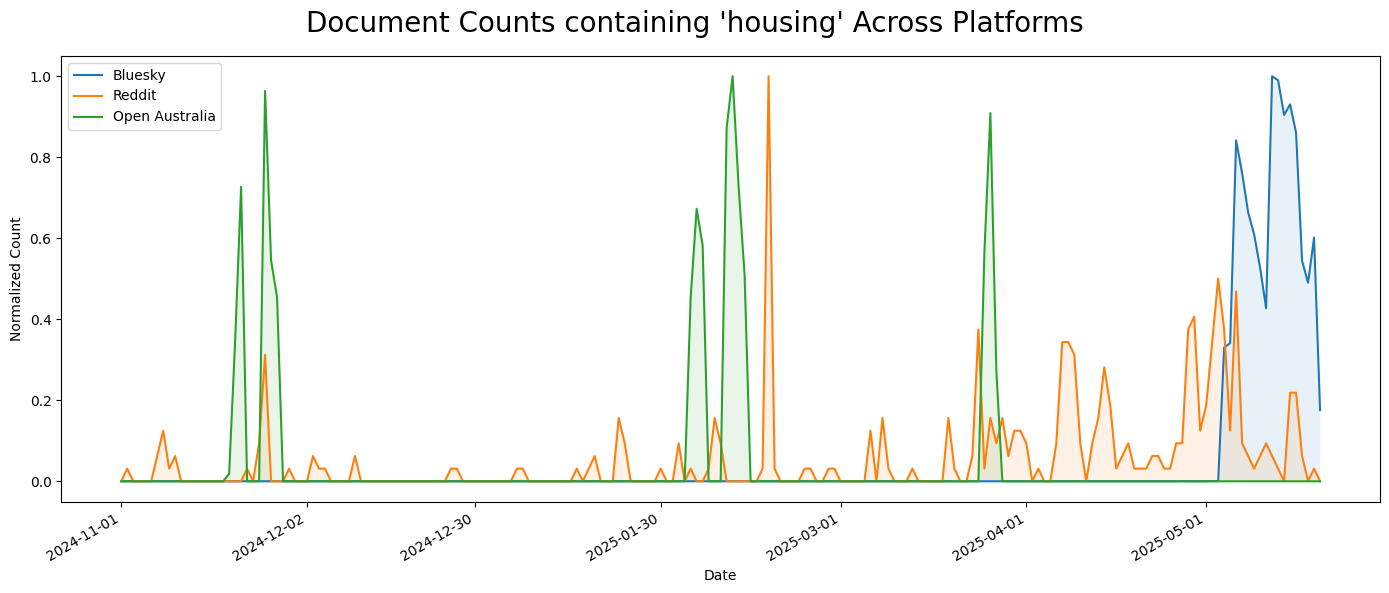

In [47]:
counts = comparison_plot_keyword_counts(["bluesky", "reddit", "openaus"], "2024-11-01", "housing", normalise=True)
plt.savefig('../docs/report_images/housing_count.png')